In [61]:
# Imports and setup
import sys
from pathlib import Path
# Ensure the repository `src` folder is on sys.path so `from utils...` works when running cells
sys.path.append(str(Path('../../../src').resolve()))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from joblib import load
from utils.variants import VARIANT_DEFS, apply_variant, prepare_variant_data_full

# --- Paths ---
BASE_DIR = Path("../../../data/out")
VAL_PATH = BASE_DIR / "dataset_validation_final.csv"
MODELS_DIR = BASE_DIR / "best_models_ml/validation_ml/models"
PLOTS_CUSTOM = BASE_DIR / "best_models_ml/validation_ml/plots_custom"
PLOTS_CUSTOM.mkdir(parents=True, exist_ok=True)

C:\Users\Camilo\AppData\Local\Temp\ipykernel_16680\3424361900.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas = pd.date_range(start="2025-07-01 00:00", periods=len(df_val_base), freq="H")


OK v2_with_calendar_lags-Lasso: 720 muestras en validación
OK v3_no_solar_lags-Lasso: 720 muestras en validación
OK v7_only_gen_enso_lags-Linear Regression: 744 muestras en validación
OK v8_only_gen_no_solar_enso_lags-XGBoost: 744 muestras en validación


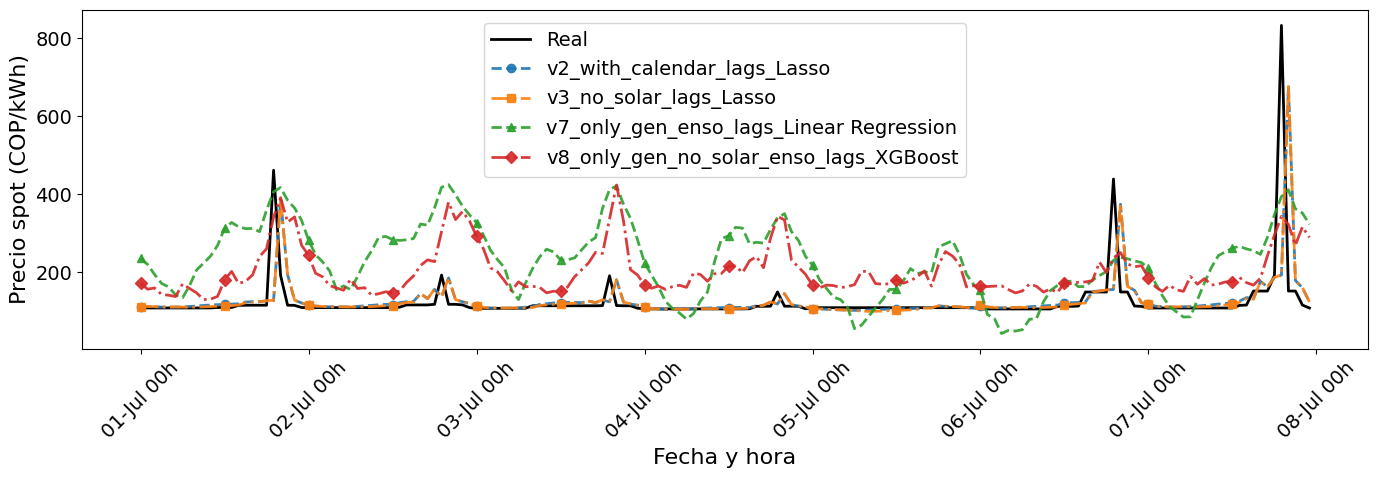

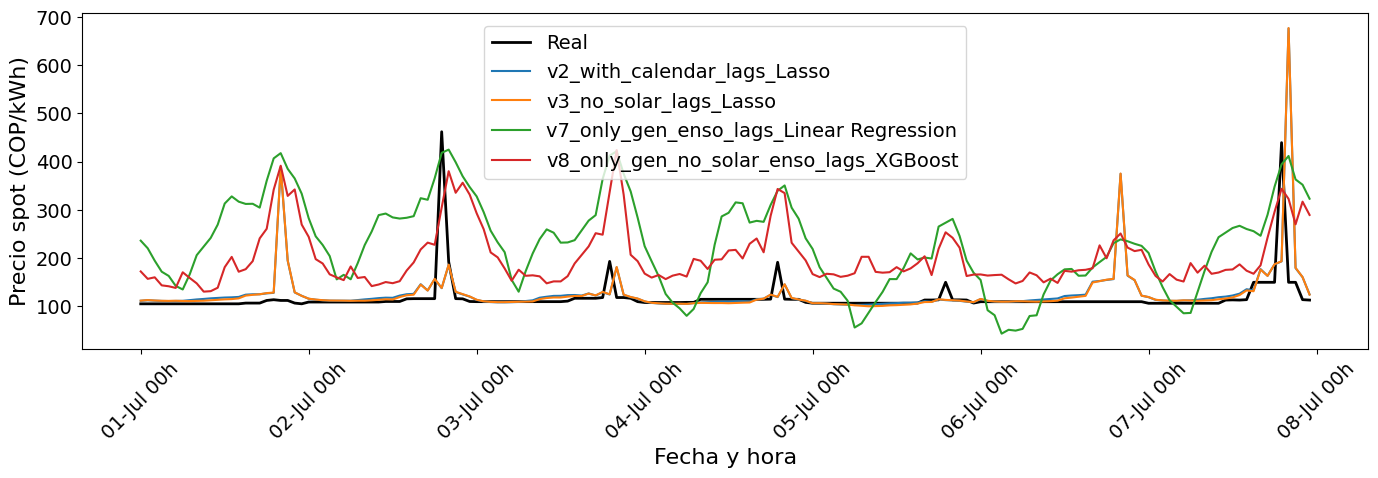

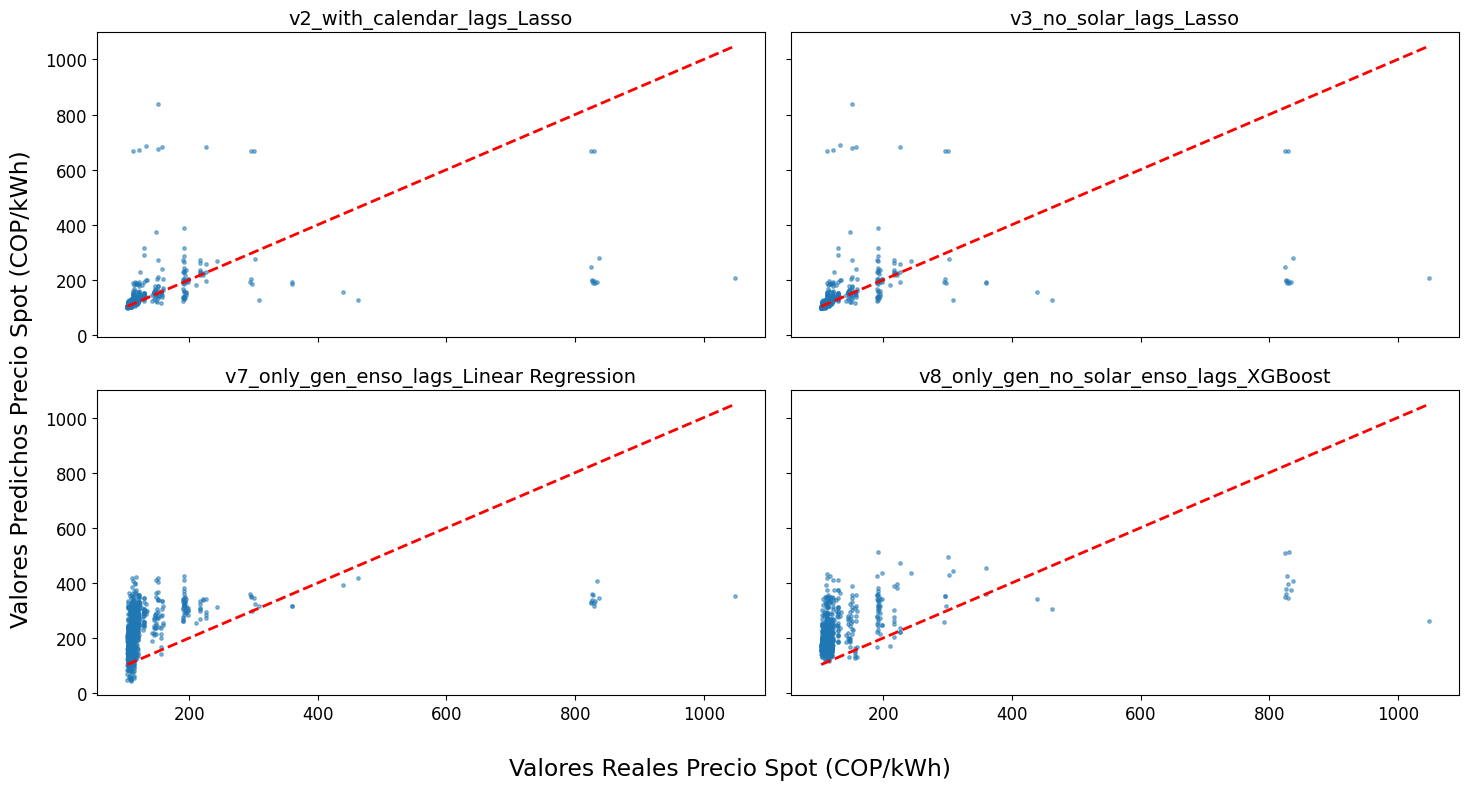

In [ ]:
# Ajustar tamaño de fuentes en matplotlib
plt.rcParams.update({
    "font.size": 14,          # tamaño base
    "axes.titlesize": 16,     # títulos de ejes
    "axes.labelsize": 16,     # etiquetas de ejes
    "xtick.labelsize": 14,    # ticks eje X
    "ytick.labelsize": 14,    # ticks eje Y
    "legend.fontsize": 14     # leyenda
})


# ----------------------------------------------------------------------
# Dataset de validación externo (base)
df_val_base = pd.read_csv(VAL_PATH)

# Configuración
n_observations = 24 * 7  # 7 días de observaciones
fechas = pd.date_range(start="2025-07-01 00:00", periods=len(df_val_base), freq="H")

top_models = [
    ("v2_with_calendar_lags", "Lasso"),
    ("v3_no_solar_lags", "Lasso"),
    ("v7_only_gen_enso_lags", "Linear Regression"),
    ("v8_only_gen_no_solar_enso_lags", "XGBoost")
]

predicciones = {}

for variant, config_name in top_models:
    try:
        # 1. Cargar modelo entrenado
        model_file = MODELS_DIR / f"{variant}_{config_name}.joblib"
        pipe = load(model_file)

        # 2. Aplicar la variante al dataset de validación
        vdef = next(v for v in VARIANT_DEFS if v["name"] == variant)
        df_val_var, _ = apply_variant(df_val_base.copy(), vdef, date_col="FECHA_HORA")

        # 3. Preparar X_val e y_val
        _, X_val, y_val = prepare_variant_data_full(df_val_var)

        # 4. Predecir
        y_pred = pipe.predict(X_val)
        predicciones[f"{variant}_{config_name}"] = (y_val, y_pred)

        print(f"OK {variant}-{config_name}: {len(y_val)} muestras en validación")

    except Exception as e:
        print(f"ERROR {variant}-{config_name}: {e}")


# ----------------------------------------------------------------------
# 1. Predicciones vs reales
plt.figure(figsize=(14,5))

# Curva real destacada
y_val_ref = next(iter(predicciones.values()))[0]
plt.plot(fechas[:n_observations], y_val_ref.values[:n_observations],
         label="Real", color="black", linewidth=2)

# Colores y estilos más visibles
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]   # azul, naranja, verde, rojo
estilos = ["--", "-.", "--", "-."]          # todos discontinuos
marcadores = ["o", "s", "^", "D"]           # círculo, cuadrado, triángulo, rombo


for (name, (y_val, y_pred)), color, estilo, marker in zip(predicciones.items(),
                                                          colores, estilos, marcadores):
    plt.plot(fechas[:n_observations], y_pred[:n_observations],
             label=name, color=color, linestyle=estilo,
             marker=marker, markersize=6, markevery=12,
             linewidth=2, alpha=0.9)

plt.xlabel("Fecha y hora")
plt.ylabel("Precio spot (COP/kWh)")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.xticks(rotation=45)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 0.99))
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "pred_solar_v1_ml.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()



# 1. Predicciones vs reales (gráfica versión 2)
plt.figure(figsize=(14,5))
plt.plot(fechas[:n_observations], y_val.values[:n_observations],
         label="Real", color="black", linewidth=2)

for name, (y_val, y_pred) in predicciones.items():
    plt.plot(fechas[:n_observations], y_pred[:n_observations], label=name)


plt.xlabel("Fecha y hora")
plt.ylabel("Precio spot (COP/kWh)")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
#plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=24))  # ticks cada 24 horas
plt.xticks(rotation=45)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 0.99))
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "pred_solar_v2_ml.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

# ----------------------------------------------------------------------
# 2. Scatter
fig, axes = plt.subplots(2, 2, figsize=(15,8), sharex=True, sharey=True)

# Aplanar la matriz de ejes para iterar linealmente
axes = axes.flatten()

lims = [y_val.min(), y_val.max()]

for ax, (name, (y_val, y_pred)) in zip(axes, predicciones.items()):
    ax.scatter(y_val, y_pred, s=6, alpha=0.5)
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_title(name, fontsize=14)
    ax.tick_params(labelsize=12)



# Una sola etiqueta global para X e Y
fig.supxlabel("Valores Reales Precio Spot (COP/kWh)")
fig.supylabel("Valores Predichos Precio Spot (COP/kWh)")
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "scatter_solar_ml.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

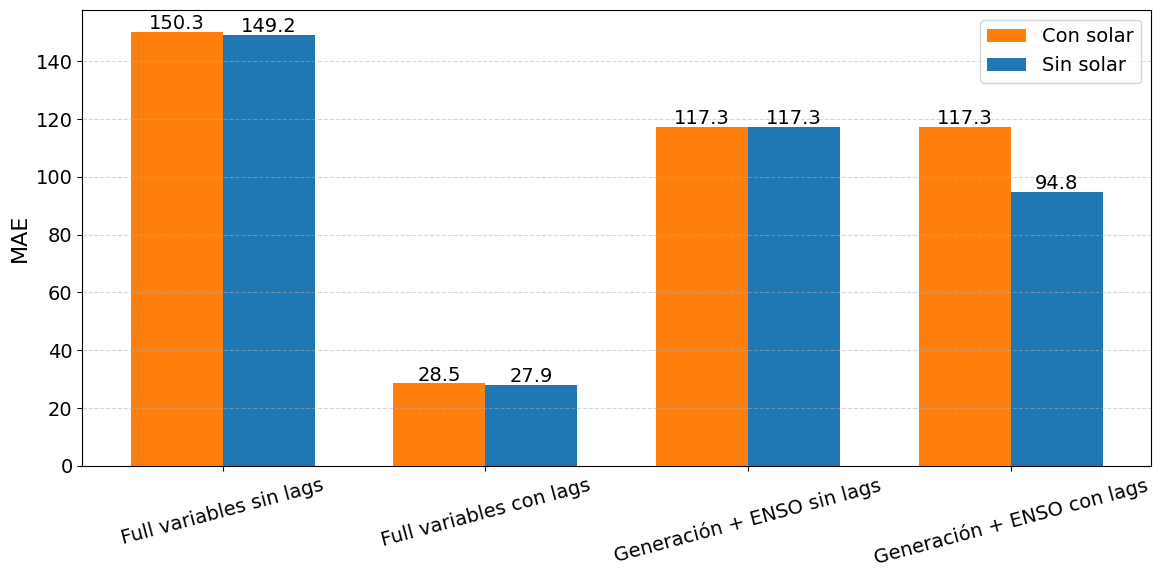

In [63]:
# --- Cargar el archivo Excel ---
ruta = "../../../data/out/best_models_ml/validation_ml/validation_ml_metrics.xlsx"
df = pd.read_excel(ruta)

# --- Definir pares de modelos por bloque ---
pares = [
    ("v2_with_calendar", "v3_no_solar"),               # Calendario sin rezagos
    ("v2_with_calendar_lags", "v3_no_solar_lags"),     # Calendario + rezagos
    ("v7_only_gen_enso", "v8_only_gen_no_solar_enso"), # ENSO sin rezagos
    ("v7_only_gen_enso_lags", "v8_only_gen_no_solar_enso_lags")  # ENSO + rezagos
]

# --- Nombres de bloques intuitivos ---
labels = [
    "Full variables sin lags",
    "Full variables con lags",
    "Generación + ENSO sin lags",
    "Generación + ENSO con lags"
]

# --- Extraer MAE por modelo ---
mae_con_solar = [df.loc[df["variant"] == a, "MAE"].values[0] for a, b in pares]
mae_sin_solar = [df.loc[df["variant"] == b, "MAE"].values[0] for a, b in pares]

# --- Preparar gráfico ---
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, mae_con_solar, width, label="Con solar", color="#ff7f0e")
plt.bar(x + width/2, mae_sin_solar, width, label="Sin solar", color="#1f77b4")

# --- Etiquetas encima de cada barra ---
for i in range(len(x)):
    plt.text(x[i] - width/2, mae_con_solar[i] + 1, f"{mae_con_solar[i]:.1f}", ha="center")
    plt.text(x[i] + width/2, mae_sin_solar[i] + 1, f"{mae_sin_solar[i]:.1f}", ha="center")

# --- Estética ---
plt.ylabel("MAE")
plt.legend(loc="upper right")
plt.xticks(x, labels, rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "barras_mae_solar_vs_no.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

